In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler

import gc


In [2]:
gc.collect()
X_scaled = pd.read_csv('test.csv')
print(X_scaled.shape)
print(X_scaled.columns)


(1829363, 113)
Index(['Unnamed: 0', 'abv', 'appearance', 'aroma', 'palate', 'taste',
       'overall', 'rating', 'style_Altbier', 'style_American Adjunct Lager',
       ...
       'style_Scottish Gruit / Ancient Herbed Ale', 'style_Smoked Beer',
       'style_Tripel', 'style_Vienna Lager', 'style_Weizenbock',
       'style_Wheatwine', 'style_Winter Warmer', 'style_Witbier',
       'user_id_encoded', 'brewery_id_encoded'],
      dtype='object', length=113)


In [3]:
pca = PCA(n_components=20, random_state=42)
X_reduced = pca.fit_transform(X_scaled)
print(X_reduced.shape)
print(X_reduced)

(1829363, 20)
[[-9.14681000e+05  1.10624387e-01 -3.95759242e-01 ... -4.81206445e-02
  -4.18880095e-02 -3.27451757e-02]
 [-9.14680000e+05 -1.96387673e+00  1.80887467e+00 ... -1.95738997e-02
  -3.35880749e-02 -4.99182369e-02]
 [-9.14679000e+05 -2.17368087e+00 -5.87093529e-01 ... -4.52714948e-04
  -1.43915287e-02 -4.74594531e-02]
 ...
 [ 9.14679000e+05 -2.80841673e+00 -5.80561505e-01 ... -4.02105322e-02
  -2.25638989e-02 -5.21804532e-02]
 [ 9.14680000e+05 -6.61152267e+00 -9.34507599e-01 ... -2.59847257e-02
   1.42639962e-02 -6.97112041e-02]
 [ 9.14681000e+05 -2.48238794e+00 -5.69235453e-01 ... -4.88624026e-02
  -3.46762050e-02 -5.57540202e-02]]


In [4]:

# Assuming X_reduced is a NumPy array, convert it to a DataFrame
X_reduced_df = pd.DataFrame(X_reduced)

# Now you can use sample to get a subset
subset_fraction = 0.1  # Use 10% of the data
X_subset = X_reduced_df.sample(frac=subset_fraction, random_state=42)
X_subset.shape


(182936, 20)

In [5]:
import time

start_time = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels_subset = dbscan.fit_predict(X_subset)
end_time = time.time()

elapsed_time = end_time - start_time
print(f"DBSCAN runtime for {len(X_subset)} samples: {elapsed_time:.2f} seconds")

DBSCAN runtime for 182936 samples: 74.32 seconds


In [6]:
l_data_size = len(X_reduced)  # Total number of samples
subset_size = len(X_subset)  # Subset size

estimated_runtime = elapsed_time * (l_data_size / subset_size) ** 2
print(f"Estimated runtime for full dataset: {estimated_runtime / 3600:.2f} hours")

Estimated runtime for full dataset: 2.06 hours


In [ ]:


gc.collect()
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_reduced)
print("Done dbscan")
# Add labels to DataFrame
#X_reduced['DBSCAN_Cluster'] = dbscan_labels





Done dbscan


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

starting PCA


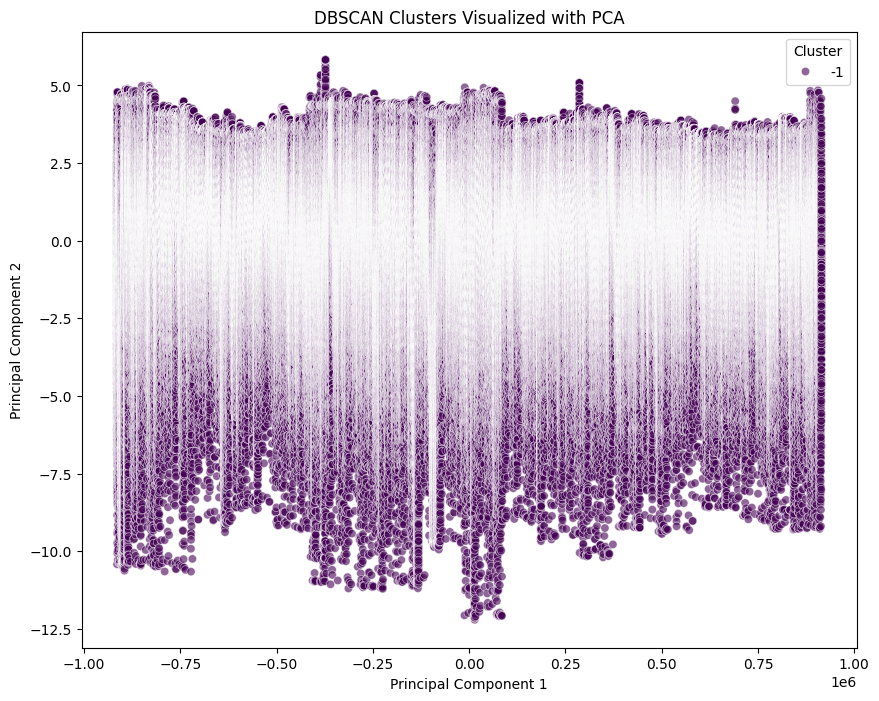

In [9]:
print("starting PCA")
# Visualize with PCA
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_reduced)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['DBSCAN_Cluster'] = dbscan_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='DBSCAN_Cluster',
    palette='viridis',
    data=pca_df,
    alpha=0.6
)
plt.title('DBSCAN Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [10]:
print(dbscan_labels)

[-1 -1 -1 ... -1 -1 -1]
